# Групповой проект №5. Deep Learning

## Ozon — категория «Мужская одежда»

Данные выгружены из сервиса MPStats

Представляют из себя аналитику продаж товаров на маркетплейсе Ozon


Взят период с 01.01.2025 по 31.12.2025


Таблица содержит **16 столбцов**.

| Столбец | Описание |
|---------|----------|
| Thumb | URL изображения товара |
| Name | Название товара |
| SKU | Идентификатор товара на Ozon |
| Niche | Ниша |
| Brand | Бренд |
| Category | Категория |
| Revenue | Выручка за период отчёта |
| Lost profit | Упущенная прибыль за период |
| Sales | Продажи за период, шт. |
| Balance | Остаток на складах |
| Turnover | Оборачиваемость |
| Frozen stocks percent | Доля замороженного остатка |
| Base price | Базовая цена |
| Rating | Рейтинг товара |
| Comments | Количество отзывов |
| Days in website | Сколько дней товар представлен на площадке |


In [28]:
import numpy as np
import pandas as pd

In [29]:
df = pd.read_csv('data/ozon_mens_clothing_2025.csv', sep=';', encoding='utf-8-sig', decimal=',')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41295796 entries, 0 to 41295795
Data columns (total 16 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Thumb                  str    
 1   Name                   str    
 2   SKU                    int64  
 3   Niche                  str    
 4   Brand                  str    
 5   Category               str    
 6   Revenue                int64  
 7   Lost profit            float64
 8   Sales                  int64  
 9   Balance                int64  
 10  Turnover               float64
 11  Frozen stocks percent  float64
 12  Base price             int64  
 13  Rating                 float64
 14  Comments               int64  
 15  Days in website        int64  
dtypes: float64(4), int64(7), str(5)
memory usage: 4.9 GB


## EDA

In [30]:
print('Размер таблицы:', df.shape)
print('Дубликаты:', df.duplicated('SKU').sum())

Размер таблицы: (41295796, 16)
Дубликаты: 0


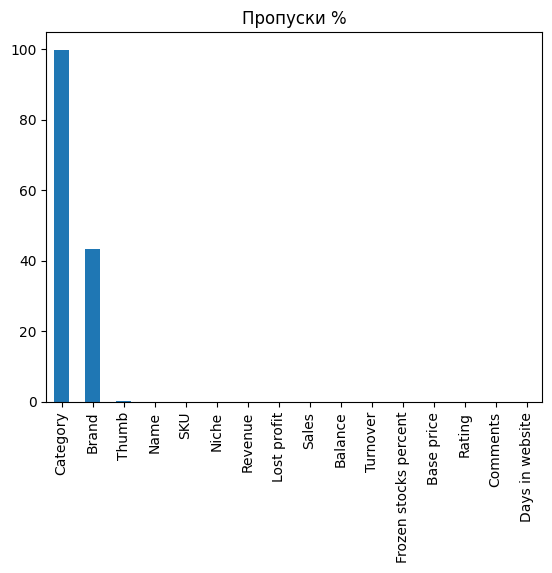

Thumb                     0.100407
Name                      0.000005
SKU                       0.000000
Niche                     0.000000
Brand                    43.320613
Category                 99.865260
Revenue                   0.000000
Lost profit               0.000000
Sales                     0.000000
Balance                   0.000000
Turnover                  0.000000
Frozen stocks percent     0.000000
Base price                0.000000
Rating                    0.000000
Comments                  0.000000
Days in website           0.000000
dtype: float64

In [31]:
import matplotlib.pyplot as plt
percent_missing = df.isna().mean() * 100
percent_missing.sort_values(ascending=False).plot.bar()
plt.title('Пропуски %')
plt.show()
percent_missing

In [32]:
df['Brand'] = df['Brand'].fillna('Unknown')
df = df.drop(columns=['Category'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41295796 entries, 0 to 41295795
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Thumb                  str    
 1   Name                   str    
 2   SKU                    int64  
 3   Niche                  str    
 4   Brand                  str    
 5   Revenue                int64  
 6   Lost profit            float64
 7   Sales                  int64  
 8   Balance                int64  
 9   Turnover               float64
 10  Frozen stocks percent  float64
 11  Base price             int64  
 12  Rating                 float64
 13  Comments               int64  
 14  Days in website        int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 4.6 GB


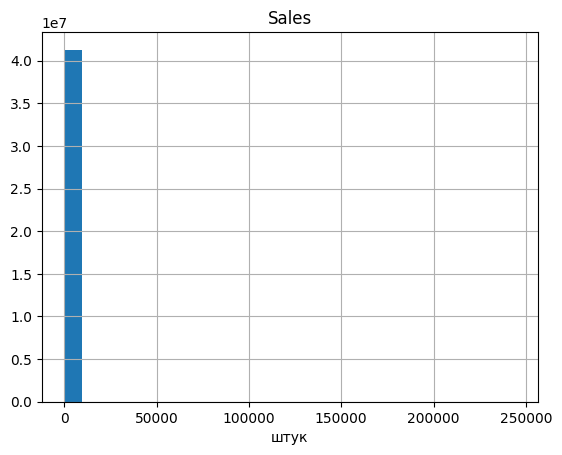

In [33]:
df['Sales'].hist(bins=25)
plt.title('Sales')
plt.xlabel('штук')
plt.show()

In [34]:
zero_sales = (df['Sales'] == 0).sum()
with_sales = (df['Sales'] > 0).sum()
total = len(df)

print('Всего SKU:', total)
print('Без продаж:', zero_sales)
print('С продажами:', with_sales)
print('Доля без продаж:', round(zero_sales / total * 100, 2), "%")
print('Доля с продажами:', round(with_sales / total * 100, 2), "%")

Всего SKU: 41295796
Без продаж: 39532110
С продажами: 1763686
Доля без продаж: 95.73 %
Доля с продажами: 4.27 %


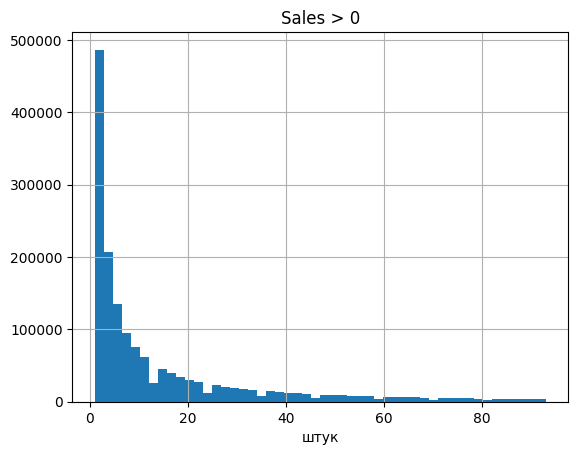

In [35]:
sales_more_then_zero = df.loc[df['Sales'] > 0, 'Sales']
sales_more_then_zero[sales_more_then_zero < sales_more_then_zero.quantile(0.9)].hist(bins=50)
plt.title('Sales > 0')
plt.xlabel('штук')
plt.show()

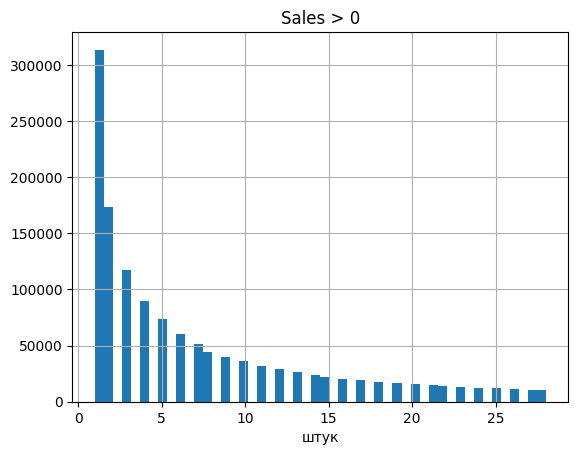

In [36]:
sales_more_then_zero = df.loc[df['Sales'] > 0, 'Sales']
sales_more_then_zero[sales_more_then_zero < sales_more_then_zero.quantile(0.75)].hist(bins=50)
plt.title('Sales > 0')
plt.xlabel('штук')
plt.show()

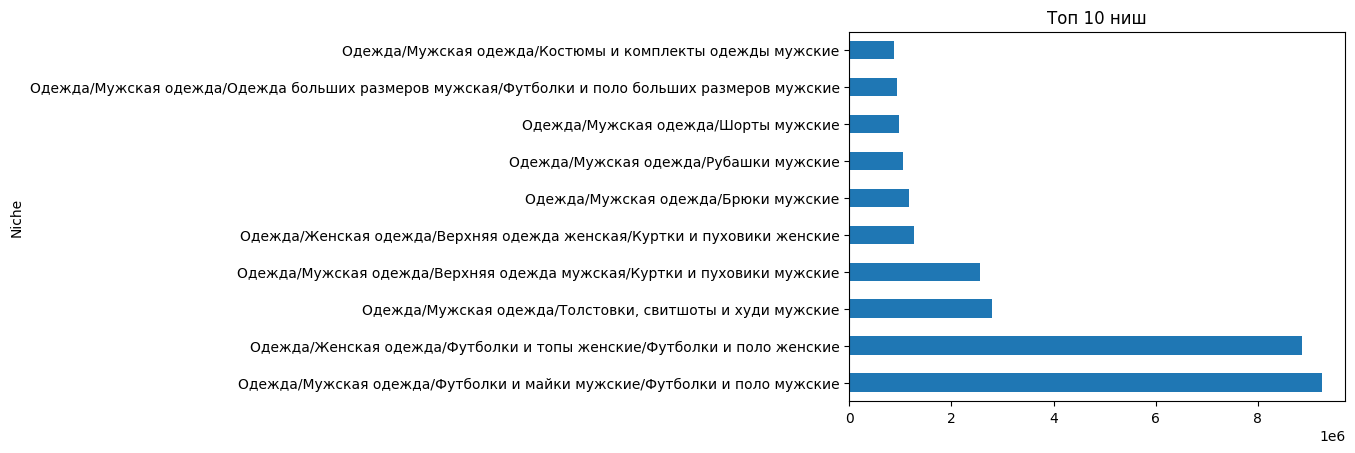

In [37]:
df['Niche'].value_counts().head(10).plot.barh()
plt.title('Топ 10 ниш')
plt.show()

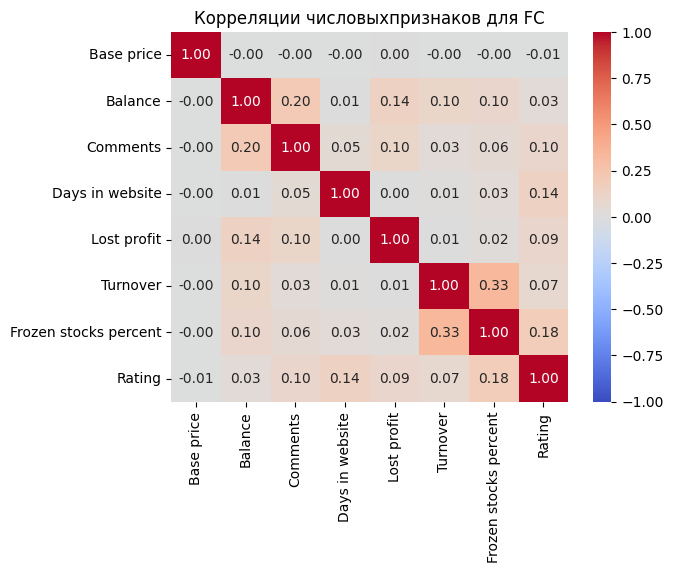

In [39]:
import seaborn as sns

num_features = [
    'Base price', 'Balance', 'Comments', 'Days in website',
    'Lost profit', 'Turnover', 'Frozen stocks percent', 'Rating'
]
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляции числовыхпризнаков для FC')
plt.show()